<a href="https://colab.research.google.com/github/ahmadoarnaout-netizen/LOAN-APPROVAL-PREDICTION-/blob/main/LOAN_APPROVAL_PREDICTION_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1: Importing the Dataset


In [ ]:
# Importing the dataset (data1, data2)
data1 = read.csv("/content/data_1.csv")
head(data1)
data2 = read.csv("/content/data_2.csv")
head(data2)



,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<chr>,<chr>
1,LP001002,Male,No,0,Graduate,No,5849,0,NA,360,1,Urban,Y
2,LP001003,Male,Yes,1,Graduate,No,4583,1508,128,360,1,Rural,N
3,LP001005,Male,Yes,0,Graduate,Yes,3000,0,66,360,1,Urban,Y
4,LP001006,Male,Yes,0,Not Graduate,No,2583,2358,120,360,1,Urban,Y
5,LP001008,Male,No,0,Graduate,No,6000,0,141,360,1,Urban,Y
6,LP001011,Male,Yes,2,Graduate,Yes,5417,4196,267,360,1,Urban,Y


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<chr>,<chr>
1,LP002648,Male,Yes,0,Graduate,No,2130,6666,70,180,1,Semiurban,N
2,LP002652,Male,No,0,Graduate,No,5815,3666,311,360,1,Rural,N
3,LP002659,Male,Yes,3+,Graduate,No,3466,3428,150,360,1,Rural,Y
4,LP002670,Female,Yes,2,Graduate,No,2031,1632,113,480,1,Semiurban,Y
5,LP002682,Male,Yes,,Not Graduate,No,3074,1800,123,360,0,Semiurban,N
6,LP002683,Male,No,0,Graduate,No,4683,1915,185,360,1,Semiurban,N


# Step 2: Merging the two tables

In [ ]:
library(dplyr)

full_data <- rbind(data1, data2)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




The training and test datasets were merged to apply consistent data cleaning and preprocessing steps across all observations.

***Note:*** The dataset was provided in two separate files. Since both files contained the same columns, they were combined using row binding (rbind) to create one complete dataset for analysis.

# Step 3 : Data Structure

### **1. Getting the Shape of the Dataset**



In [ ]:
# Viewing the data
head(full_data)
# Checking how many columns and rows
dim(full_data)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<chr>,<chr>
1,LP001002,Male,No,0,Graduate,No,5849,0,NA,360,1,Urban,Y
2,LP001003,Male,Yes,1,Graduate,No,4583,1508,128,360,1,Rural,N
3,LP001005,Male,Yes,0,Graduate,Yes,3000,0,66,360,1,Urban,Y
4,LP001006,Male,Yes,0,Not Graduate,No,2583,2358,120,360,1,Urban,Y
5,LP001008,Male,No,0,Graduate,No,6000,0,141,360,1,Urban,Y
6,LP001011,Male,Yes,2,Graduate,Yes,5417,4196,267,360,1,Urban,Y


[1] 614  13

### **2. Inspecting the Types of Columns**

In [ ]:
str(full_data)

'data.frame':	614 obs. of  13 variables:
 $ Loan_ID          : chr  "LP001002" "LP001003" "LP001005" "LP001006" ...
 $ Gender           : chr  "Male" "Male" "Male" "Male" ...
 $ Married          : chr  "No" "Yes" "Yes" "Yes" ...
 $ Dependents       : chr  "0" "1" "0" "0" ...
 $ Education        : chr  "Graduate" "Graduate" "Graduate" "Not Graduate" ...
 $ Self_Employed    : chr  "No" "No" "Yes" "No" ...
 $ ApplicantIncome  : int  5849 4583 3000 2583 6000 5417 2333 3036 4006 12841 ...
 $ CoapplicantIncome: num  0 1508 0 2358 0 ...
 $ LoanAmount       : int  NA 128 66 120 141 267 95 158 168 349 ...
 $ Loan_Amount_Term : int  360 360 360 360 360 360 360 360 360 360 ...
 $ Credit_History   : int  1 1 1 1 1 1 1 0 1 1 ...
 $ Property_Area    : chr  "Urban" "Rural" "Urban" "Urban" ...
 $ Loan_Status      : chr  "Y" "N" "Y" "Y" ...


### **3. Detecting Null Values**

In [ ]:
sum(is.na(full_data))

[1] 86

***Note:*** Before cleaning, the structure and summary of the dataset were explored using functions like str(), summary(), and colSums(is.na()). This helped identify missing values, incorrect data types, and inconsistencies that needed to be addressed before analysis.

### **4. Deriving Statistical Information**
Statisitical information includes : columns, such as mean, median, minimum, maximum, and quartiles.



In [ ]:
summary(full_data)

   Loan_ID             Gender            Married           Dependents       
 Length:614         Length:614         Length:614         Length:614        
 Class :character   Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character   Mode  :character  
                                                                            
                                                                            
                                                                            
                                                                            
  Education         Self_Employed      ApplicantIncome CoapplicantIncome
 Length:614         Length:614         Min.   :  150   Min.   :    0    
 Class :character   Class :character   1st Qu.: 2878   1st Qu.:    0    
 Mode  :character   Mode  :character   Median : 3812   Median : 1188    
                                       Mean   : 5403   Mean   : 1621    
                   

In [ ]:
anyDuplicated(full_data)

[1] 0

# Step 4 : Data Cleaning
In this section we need to check null values for both numeric and string values


### **1. Dealing with null values**

In [ ]:
library(dplyr)

full_data <- distinct(full_data)
head(full_data)

# Checking missing numbers in each columns
col_null_values <- colnames(full_data)[colSums(is.na(full_data)) > 0]
col_null_values
# Checking missing empty string in each columns
colnames(full_data)[colSums(sapply(full_data, function(x) trimws(x) == "")) > 0]


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<chr>,<chr>
1,LP001002,Male,No,0,Graduate,No,5849,0,NA,360,1,Urban,Y
2,LP001003,Male,Yes,1,Graduate,No,4583,1508,128,360,1,Rural,N
3,LP001005,Male,Yes,0,Graduate,Yes,3000,0,66,360,1,Urban,Y
4,LP001006,Male,Yes,0,Not Graduate,No,2583,2358,120,360,1,Urban,Y
5,LP001008,Male,No,0,Graduate,No,6000,0,141,360,1,Urban,Y
6,LP001011,Male,Yes,2,Graduate,Yes,5417,4196,267,360,1,Urban,Y


[1] "LoanAmount"       "Loan_Amount_Term" "Credit_History"

[1] "Gender"        "Married"       "Dependents"    "Self_Employed"
[5] NA              NA              NA

### **2. Fillng nulls(numeric values)**

In [ ]:
#Filling the gap in each Loan_Amount_Term column
full_data$LoanAmount<- as.numeric(gsub(",", "",full_data$LoanAmount))
full_data$LoanAmount[is.na(full_data$LoanAmount)] <- median(full_data$LoanAmount, na.rm = TRUE)



Missing values in LoanAmount were replaced with the median value. The median is used because it is less affected by extreme values than the mean.

In [ ]:
#Filling the gap in each Loan_Amount_Term column
full_data$Loan_Amount_Term[is.na(full_data$Loan_Amount_Term)] <- median(full_data$Loan_Amount_Term, na.rm = TRUE)

Missing values in Loan_Amount_Term were replaced with the median to maintain a realistic and stable representation of loan durations.

In [ ]:
full_data$Credit_History[!full_data$Credit_History %in% c("0","1")] <- NA
full_data$Credit_History[is.na(full_data$Credit_History)] <-  names(which.max(table(full_data$Credit_History)))
full_data$Credit_History <- as.numeric(full_data$Credit_History)

Invalid or blank entries in Credit_History were converted into missing values. These were then replaced using the most frequent value (mode). Finally, the variable was converted into numeric form (0 = poor credit history, 1 = good credit history).

In [ ]:
sum(is.na(full_data))

[1] 0

### **3. Fillng nulls(Empty String)**

In [ ]:
#Gender


full_data$Gender <- as.character(full_data$Gender)
mode_gender <- names(which.max(table(full_data$Gender)))
full_data$Gender[full_data$Gender == ""] <- NA
full_data$Gender[is.na(full_data$Gender)] <- mode_gender
full_data$Gender <- ifelse(full_data$Gender == "Male", 1, 0)

Missing values in the Gender column were replaced using the most frequent category (mode). The variable was then converted into numeric form (Male = 1, Female = 0) to make it suitable for analysis.

In [ ]:
#Married
full_data$Married[full_data$Married == ""] <- NA
full_data$Married <- ifelse(full_data$Married == "Yes", 1, 0)


Blank or missing entries in the Married column were replaced with the most frequent value. The column was then encoded numerically (Yes = 1, No = 0).

In [ ]:
#Self Employed
full_data$Self_Employed[full_data$Self_Employed == ""] <- NA

full_data$Self_Employed[is.na(full_data$Self_Employed)] <-
  names(which.max(table(full_data$Self_Employed)))

full_data$Self_Employed <- ifelse(full_data$Self_Employed == "Yes", 1, 0)

Missing values were replaced with the most common category. The variable was converted into numeric format (Yes = 1, No = 0) for easier analysis.

In [ ]:
#Graduated
full_data$Education <- ifelse(full_data$Education == "Graduate",1,0)

In [ ]:
#Dependent
full_data$Dependents[full_data$Dependents == "3+"] <- 3
full_data$Dependents <- as.numeric(full_data$Dependents)
full_data$Dependents[is.na(full_data$Dependents)] <- median(full_data$Dependents, na.rm = TRUE)


The Dependents variable was cleaned by converting it to numeric format and replacing missing values with the median

In [ ]:
sum(is.na(full_data))
unique(full_data$Credit_History)
View(full_data)

[1] 3

[1] 1 0

Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
LP001002,1,0,0,1,0,5849,0,128,360,1,Urban,Y
LP001003,1,1,1,1,0,4583,1508,128,360,1,Rural,N
LP001005,1,1,0,1,1,3000,0,66,360,1,Urban,Y
LP001006,1,1,0,0,0,2583,2358,120,360,1,Urban,Y
LP001008,1,0,0,1,0,6000,0,141,360,1,Urban,Y
LP001011,1,1,2,1,1,5417,4196,267,360,1,Urban,Y
LP001013,1,1,0,0,0,2333,1516,95,360,1,Urban,Y
LP001014,1,1,3,1,0,3036,2504,158,360,0,Semiurban,N
LP001018,1,1,2,1,0,4006,1526,168,360,1,Urban,Y


In [ ]:
sum(is.na(full_data$Gender))
colSums(is.na(full_data))


[1] 0

Loan_ID            Gender           Married        Dependents 
                0                 0                 3                 0 
        Education     Self_Employed   ApplicantIncome CoapplicantIncome 
                0                 0                 0                 0 
       LoanAmount  Loan_Amount_Term    Credit_History     Property_Area 
                0                 0                 0                 0 
      Loan_Status 
                0

### **4. Fixing Data Type Structure**

In [ ]:
str(full_data)

'data.frame':	614 obs. of  13 variables:
 $ Loan_ID          : chr  "LP001002" "LP001003" "LP001005" "LP001006" ...
 $ Gender           : num  1 1 1 1 1 1 1 1 1 1 ...
 $ Married          : num  0 1 1 1 0 1 1 1 1 1 ...
 $ Dependents       : num  0 1 0 0 0 2 0 3 2 1 ...
 $ Education        : num  1 1 1 0 1 1 0 1 1 1 ...
 $ Self_Employed    : num  0 0 1 0 0 1 0 0 0 0 ...
 $ ApplicantIncome  : int  5849 4583 3000 2583 6000 5417 2333 3036 4006 12841 ...
 $ CoapplicantIncome: num  0 1508 0 2358 0 ...
 $ LoanAmount       : num  128 128 66 120 141 267 95 158 168 349 ...
 $ Loan_Amount_Term : num  360 360 360 360 360 360 360 360 360 360 ...
 $ Credit_History   : num  1 1 1 1 1 1 1 0 1 1 ...
 $ Property_Area    : chr  "Urban" "Rural" "Urban" "Urban" ...
 $ Loan_Status      : chr  "Y" "N" "Y" "Y" ...


In [ ]:
head(full_data)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,LP001002,1,0,0,1,0,5849,0,128,360,1,Urban,Y
2,LP001003,1,1,1,1,0,4583,1508,128,360,1,Rural,N
3,LP001005,1,1,0,1,1,3000,0,66,360,1,Urban,Y
4,LP001006,1,1,0,0,0,2583,2358,120,360,1,Urban,Y
5,LP001008,1,0,0,1,0,6000,0,141,360,1,Urban,Y
6,LP001011,1,1,2,1,1,5417,4196,267,360,1,Urban,Y


In [ ]:
str(full_data)

'data.frame':	614 obs. of  13 variables:
 $ Loan_ID          : chr  "LP001002" "LP001003" "LP001005" "LP001006" ...
 $ Gender           : num  1 1 1 1 1 1 1 1 1 1 ...
 $ Married          : num  0 1 1 1 0 1 1 1 1 1 ...
 $ Dependents       : num  0 1 0 0 0 2 0 3 2 1 ...
 $ Education        : num  1 1 1 0 1 1 0 1 1 1 ...
 $ Self_Employed    : num  0 0 1 0 0 1 0 0 0 0 ...
 $ ApplicantIncome  : int  5849 4583 3000 2583 6000 5417 2333 3036 4006 12841 ...
 $ CoapplicantIncome: num  0 1508 0 2358 0 ...
 $ LoanAmount       : num  128 128 66 120 141 267 95 158 168 349 ...
 $ Loan_Amount_Term : num  360 360 360 360 360 360 360 360 360 360 ...
 $ Credit_History   : num  1 1 1 1 1 1 1 0 1 1 ...
 $ Property_Area    : chr  "Urban" "Rural" "Urban" "Urban" ...
 $ Loan_Status      : chr  "Y" "N" "Y" "Y" ...


# Step 4 : Feature Engineering (Creating New Variables)

In [ ]:
# Adding a new column to our data Total income
full_data$TotalIncome <- full_data$ApplicantIncome + full_data$CoapplicantIncome
# Adding a new column to our data Total Income_loan_Ratio
full_data$Income_Loan_Ratio <- full_data$TotalIncome / full_data$LoanAmount
head(full_data)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,Income_Loan_Ratio
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>
1,LP001002,1,0,0,1,0,5849,0,128,360,1,Urban,Y,5849,45.69531
2,LP001003,1,1,1,1,0,4583,1508,128,360,1,Rural,N,6091,47.58594
3,LP001005,1,1,0,1,1,3000,0,66,360,1,Urban,Y,3000,45.45455
4,LP001006,1,1,0,0,0,2583,2358,120,360,1,Urban,Y,4941,41.17500
5,LP001008,1,0,0,1,0,6000,0,141,360,1,Urban,Y,6000,42.55319
6,LP001011,1,1,2,1,1,5417,4196,267,360,1,Urban,Y,9613,36.00375


***Note:*** I created a new variable called TotalIncome to better represent the household’s financial capacity, which is more relevant for loan approval decisions than using only the applicant’s income.

I created a new feature called Income_Loan_Ratio to measure how large the requested loan is compared to the applicant’s total income. This helps better understand repayment capacity and financial risk.

### **1. Analyze Loan Approval by Credit History**

In [ ]:
table(full_data$Loan_Status, full_data$Credit_History)

prop.table(table(full_data$Loan_Status, full_data$Credit_History), 2)

   
      0   1
  N  82 110
  Y   7 415

   
             0          1
  N 0.92134831 0.20952381
  Y 0.07865169 0.79047619

***Note:*** Credit history appears to be the strongest factor influencing loan approval. Applicants with a positive credit history have a much higher approval rate compared to those with poor or missing credit history.

### **2. Analyze Loan Approval by Property Area**

In [ ]:
table(full_data$Loan_Status, full_data$Property_Area)
prop.table(table(full_data$Loan_Status, full_data$Property_Area), margin = 2)

   
    Rural Semiurban Urban
  N    69        54    69
  Y   110       179   133

   
        Rural Semiurban     Urban
  N 0.3854749 0.2317597 0.3415842
  Y 0.6145251 0.7682403 0.6584158

### 3. **Analyze Loan Approval by Income-Loan Ratio**


In [ ]:
aggregate(Income_Loan_Ratio ~ Loan_Status, data = full_data, mean)

Loan_Status,Income_Loan_Ratio
<chr>,<dbl>
N,49.85591
Y,51.79595


Applicants with approved loans tend to have a slightly higher income-to-loan ratio than rejected applicants, indicating that repayment capacity influences loan approval decisions. However, the small difference suggests this factor works together with other financial and credit-related variables rather than acting alone.

### 4. **Analyze Loan Approval by Loan Amount**

In [ ]:
aggregate(LoanAmount ~ Loan_Status, data = full_data, mean)

Loan_Status,LoanAmount
<chr>,<dbl>
N,149.8906
Y,143.8697


### **5. Analyze Education by Loan status**

In [ ]:
table(full_data$Education, full_data$Loan_Status)
prop.table(table(full_data$Education , full_data$Loan_Status), margin = 1)

   
      N   Y
  0  52  82
  1 140 340

   
            N         Y
  0 0.3880597 0.6119403
  1 0.2916667 0.7083333

Rejected applicants tend to request slightly higher loan amounts on average, which may be associated with higher lending risk.

# 5. Data Visualization

### **1. Approved Loans by Property Area**

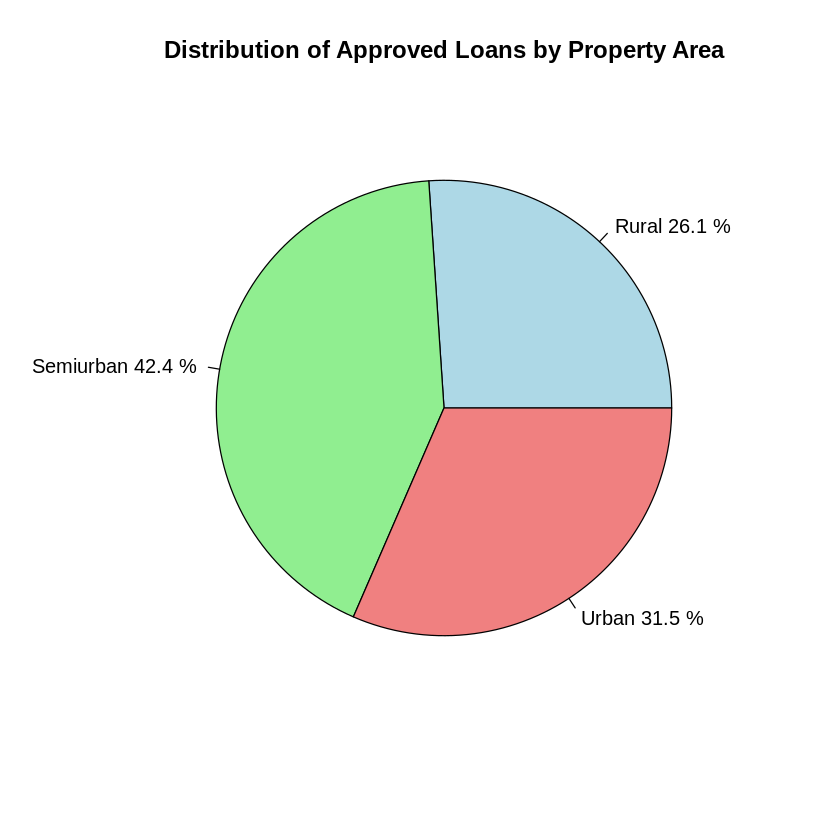

In [ ]:

approved <- full_data[full_data$Loan_Status == "Y", ]

area_counts <- table(approved$Property_Area)

area_percent <- round(prop.table(area_counts) * 100, 1)

labels <- paste(names(area_percent), area_percent, "%")

pie(area_counts,
    labels = labels,
    main = "Distribution of Approved Loans by Property Area",
    col = c("lightblue", "lightgreen", "lightcoral"))

***Note:*** People who live in semi-urban areas tend to have a higher chance of having their loans accepted.

### **2. Trend Between Applicant Income and Loan Amount**

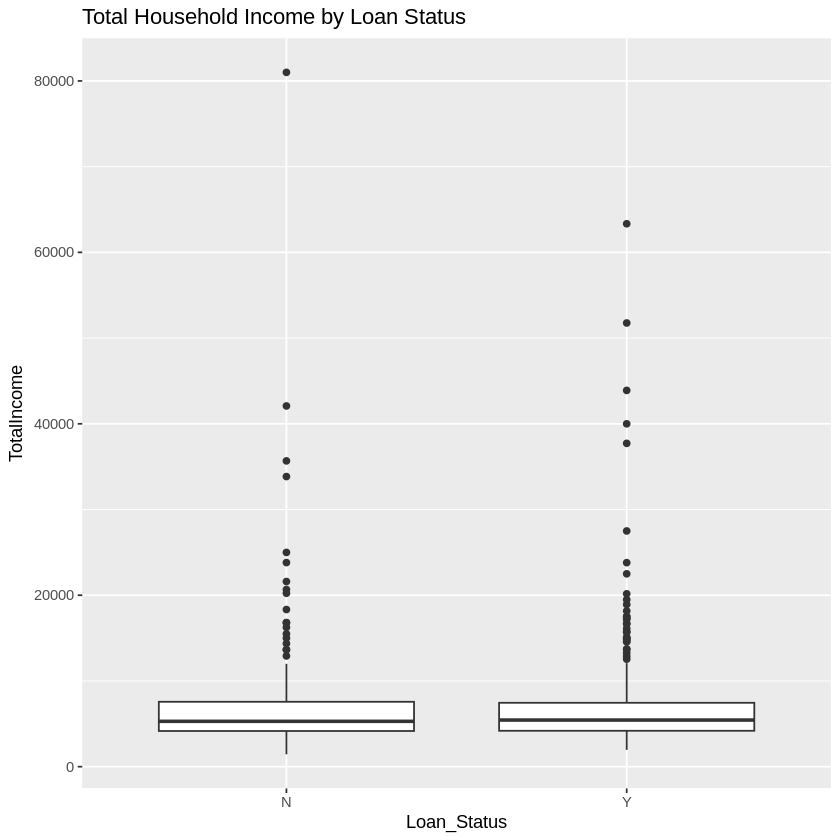

In [ ]:

library(ggplot2)

ggplot(full_data, aes(x = Loan_Status, y = TotalIncome)) +
  geom_boxplot() +
  ggtitle("Total Household Income by Loan Status")

This boxplot compares total household income between approved and rejected loan applications. It shows that approved applicants generally tend to have higher incomes, suggesting that income level plays an important role in loan approval decisions.

### **3. Comparison of Household Income by Loan Approval Status**

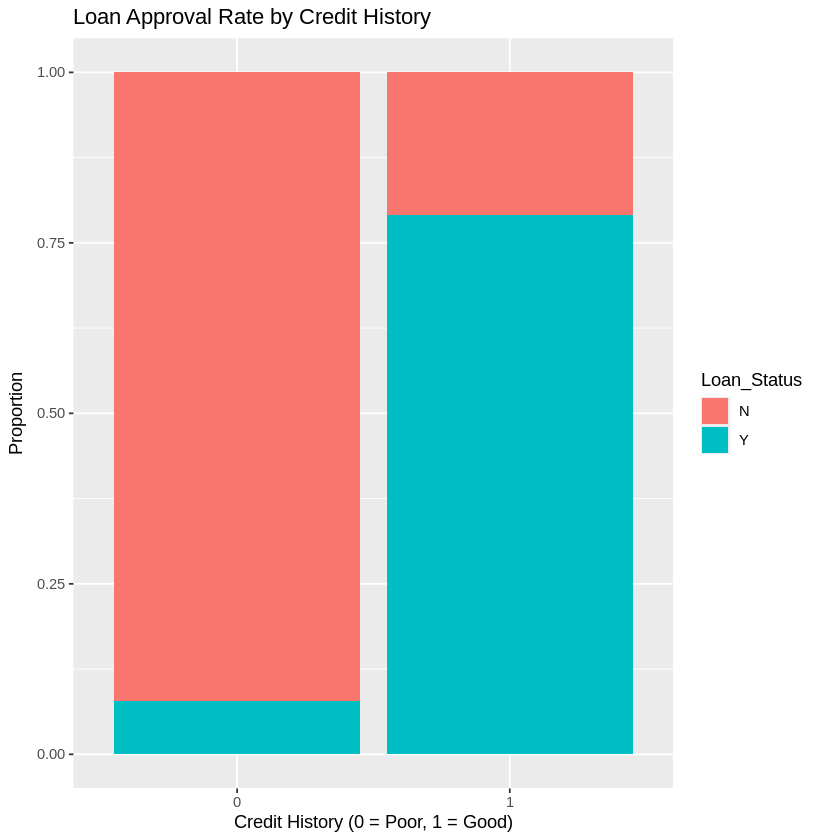

In [ ]:
ggplot(full_data, aes(x = factor(Credit_History), fill = Loan_Status)) +
  geom_bar(position = "fill") +
  labs(title = "Loan Approval Rate by Credit History",
       x = "Credit History (0 = Poor, 1 = Good)",
       y = "Proportion")

This chart shows how loan approval proportions vary depending on the property area, helping identify whether location influences approval decisions.

# **Step** 6: Final Insights and Conclusion

## Final Insights: Factors Influencing Loan Approval

1. After cleaning and preparing the dataset,
several features appear to influence loan approval decisions.

2. Credit History is the most important factor. Applicants with a positive credit history are far more likely to be approved.

3. Total Household Income also plays a major role, as approved applicants generally have higher combined income.

4. The Income_Loan_Ratio indicates that applicants whose income is large relative to the requested loan amount have higher approval rates, highlighting the importance of loan affordability.

5. Loan Amount shows a moderate effect, where larger requested amounts are slightly associated with rejections.

6. Property Area shows minor differences, with semi-urban and urban applicants having marginally higher approval rates.

7. These findings suggest that financial reliability, income strength, and repayment capacity are central to loan approval decisions.


